In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []  
TARGET = ["Theta", "X", "Y"] 
PREDICTORS = ["PwmD", "PwmE", "WdRef", "WeRef"]   
     
TS = 0.07

for i in range(4):
    Dataset = pd.read_excel(f"../../../RotedData/Data.xlsx", f"D{i+1}")   
    Datasets.append(Dataset)

for i in range(2):   
    Dataset = pd.read_csv(f"../../../Data/Data{i + 1}.csv")  
    Datasets.append(Dataset)
    
    
for i in range(len(Datasets)):
    Dataset = Datasets[i].copy()

    for var in TARGET:
        Dataset[f"Delta{var}"] = (Dataset[var].shift(1) - Dataset[var]) / TS

    for var in PREDICTORS:
        Dataset[f"s{var}"] = (Dataset[var].shift(-1) + Dataset[var]) 
    
    for var in PREDICTORS:
        Dataset[f"d{var}"] = (Dataset[var].shift(-1) - Dataset[var])

    Dataset = Dataset.dropna(subset=[f"Delta{var}" for var in TARGET])

    Datasets[i] = Dataset    

In [11]:
Datasets[0]

,Unnamed: 0,X,Y,Theta,Wd,We,WdRef,WeRef,PwmD,PwmE,...,DeltaX,DeltaY,sPwmD,sPwmE,sWdRef,sWeRef,dPwmD,dPwmE,dWdRef,dWeRef
1,0.07,0.00,0.70,0.00,0.00,0.0,3.28,3.28,0.00,0.00,...,0.0,0.0,49.25,49.25,6.56,6.56,49.25,49.25,0.00,0.00
2,0.14,0.00,0.70,0.00,0.00,0.0,3.28,3.28,49.25,49.25,...,0.0,0.0,98.50,98.50,6.56,6.56,0.00,0.00,0.00,0.00
3,0.21,0.00,0.70,0.00,0.06,0.0,3.28,3.28,49.25,49.25,...,0.0,0.0,117.32,118.16,6.56,6.56,18.82,19.66,0.00,0.00
4,0.28,0.00,0.70,0.01,0.33,0.0,3.28,3.28,68.07,68.91,...,0.0,0.0,136.14,137.82,6.50,6.50,0.00,0.00,-0.06,-0.06
5,0.35,0.00,0.70,0.01,0.20,0.0,3.22,3.22,68.07,68.91,...,0.0,0.0,151.31,155.54,6.36,6.37,15.17,17.72,-0.08,-0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
972,68.04,0.01,0.69,-0.80,0.00,0.0,0.85,2.03,-47.56,-17.83,...,0.0,0.0,-95.12,-35.66,1.70,4.06,0.00,0.00,0.00,0.00
973,68.11,0.01,0.69,-0.80,0.00,0.0,0.85,2.03,-47.56,-17.83,...,0.0,0.0,-90.03,-23.50,1.70,4.06,5.09,12.16,0.00,0.00
974,68.18,0.01,0.69,-0.80,0.00,0.0,0.85,2.03,-42.47,-5.67,...,0.0,0.0,-84.94,-11.34,1.70,4.06,0.00,0.00,0.00,0.00
975,68.25,0.01,0.69,-0.80,0.00,0.0,0.85,2.03,-42.47,-5.67,...,0.0,0.0,-79.84,0.83,1.70,4.06,5.10,12.17,0.00,0.00


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def PlotTarget(dataset, target):

    # pega a variável
    var = dataset[target].values
    delta_var = dataset[f"Delta{target}"]

    # eixo do tempo
    t = np.arange(len(var))

    plt.figure(figsize=(12,6))

    # variável
    plt.subplot(2,1,1)
    plt.plot(t, var)
    plt.title(f'{target}')
    plt.ylabel(target)
    plt.grid()

    # delta da variável
    plt.subplot(2,1,2)
    plt.plot(t, delta_var)
    plt.title(f'Δ{target}')
    plt.ylabel(f'Δ{target}')
    plt.xlabel('sample')
    plt.grid()

    plt.tight_layout()
    plt.show()

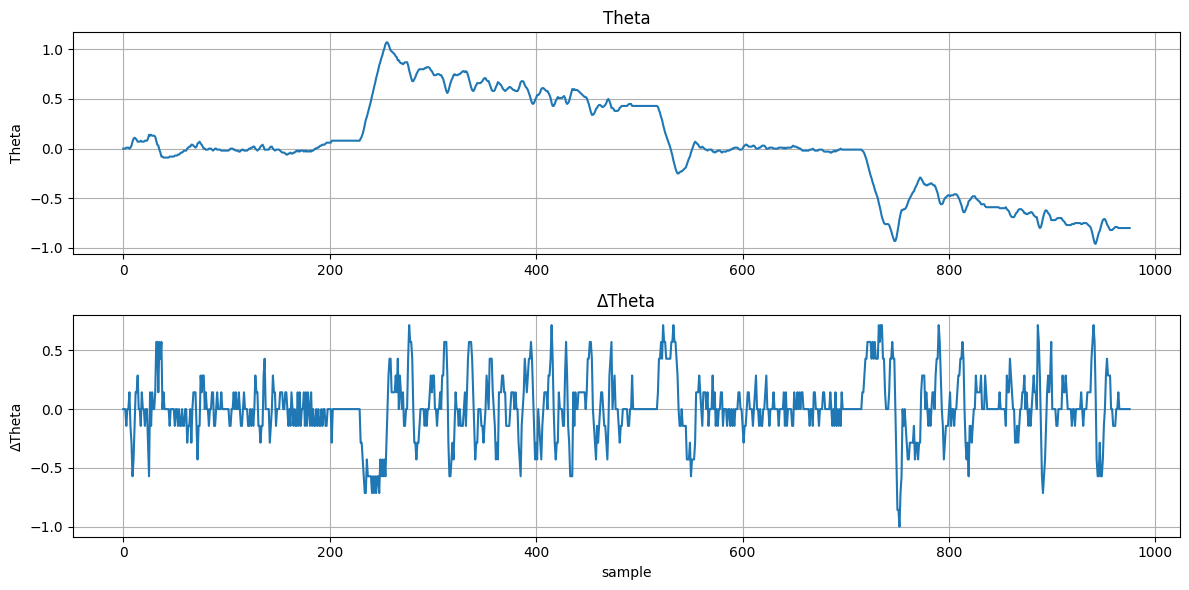

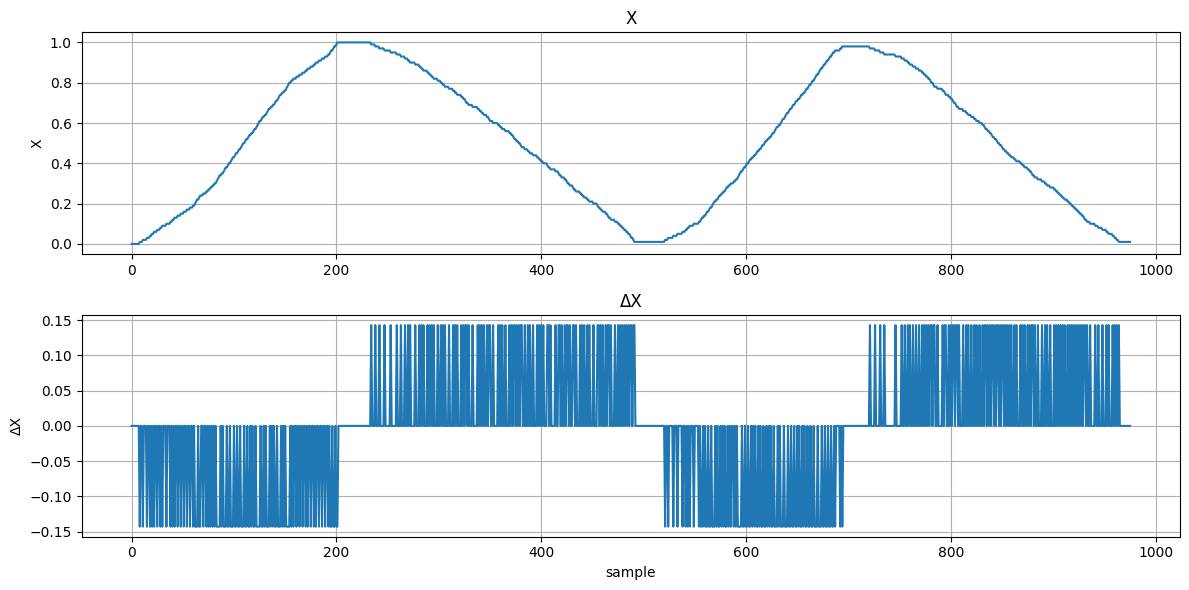

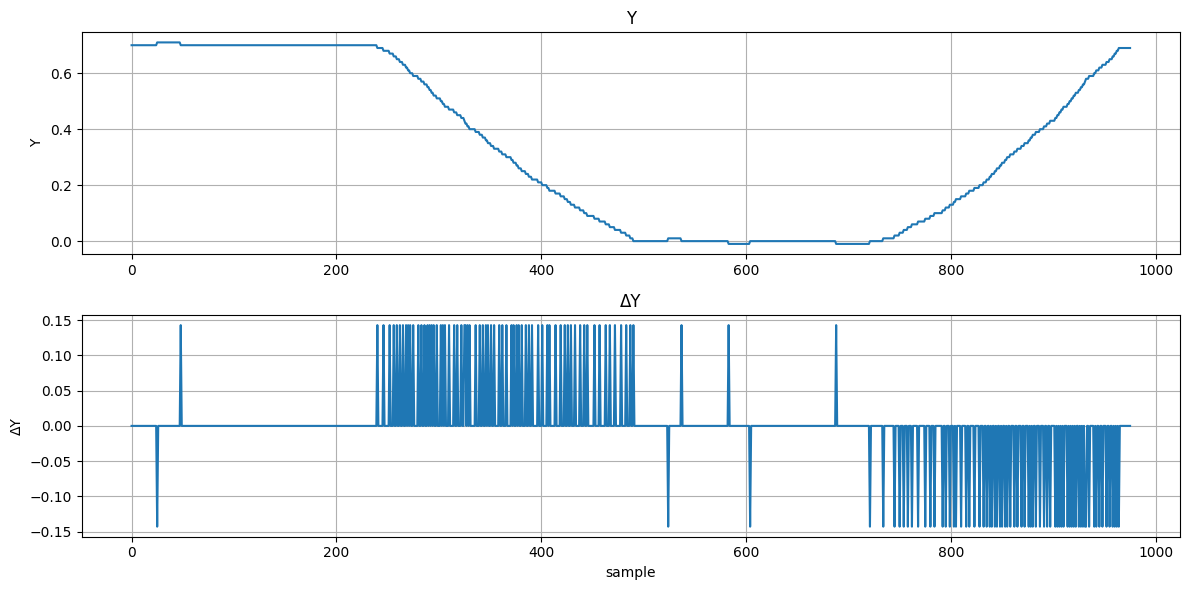

In [19]:
PlotTarget(Datasets[0], target="Theta")
PlotTarget(Datasets[0], target="X")
PlotTarget(Datasets[0], target="Y")

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def PlotPred(dataset, predictor):

    # pega a variável
    var = dataset[predictor].values
    d_var = dataset[f"d{predictor}"]
    s_var = dataset[f"s{predictor}"]

    # eixo do tempo
    t = np.arange(len(var))

    plt.figure(figsize=(12,6))

    # variável
    plt.subplot(3,1,1)
    plt.plot(t, var)
    plt.title(f'{predictor}')
    plt.ylabel(predictor)
    plt.grid()

    # delta da variável
    plt.subplot(3,1,2)
    plt.plot(t, d_var)
    plt.title(f'd{predictor}')
    plt.ylabel(f'd{predictor}')
    plt.xlabel('sample')
    plt.grid()
    
    # delta da variável
    plt.subplot(3,1,3)
    plt.plot(t, s_var)
    plt.title(f's{predictor}')
    plt.ylabel(f's{predictor}')
    plt.xlabel('sample')
    plt.grid()

    plt.tight_layout()
    plt.show()

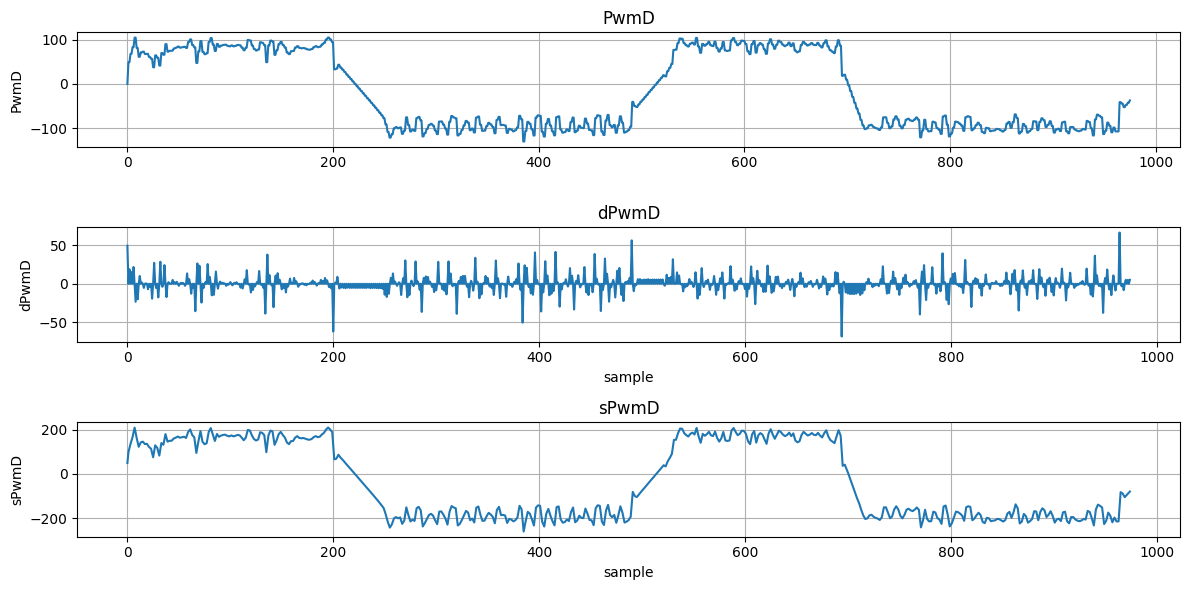

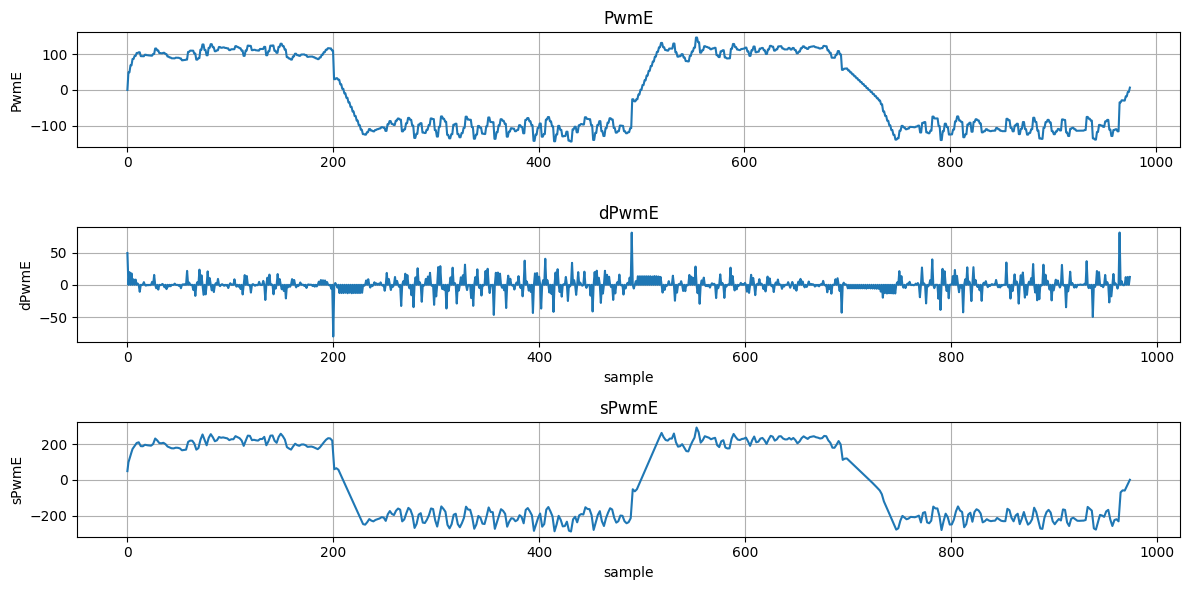

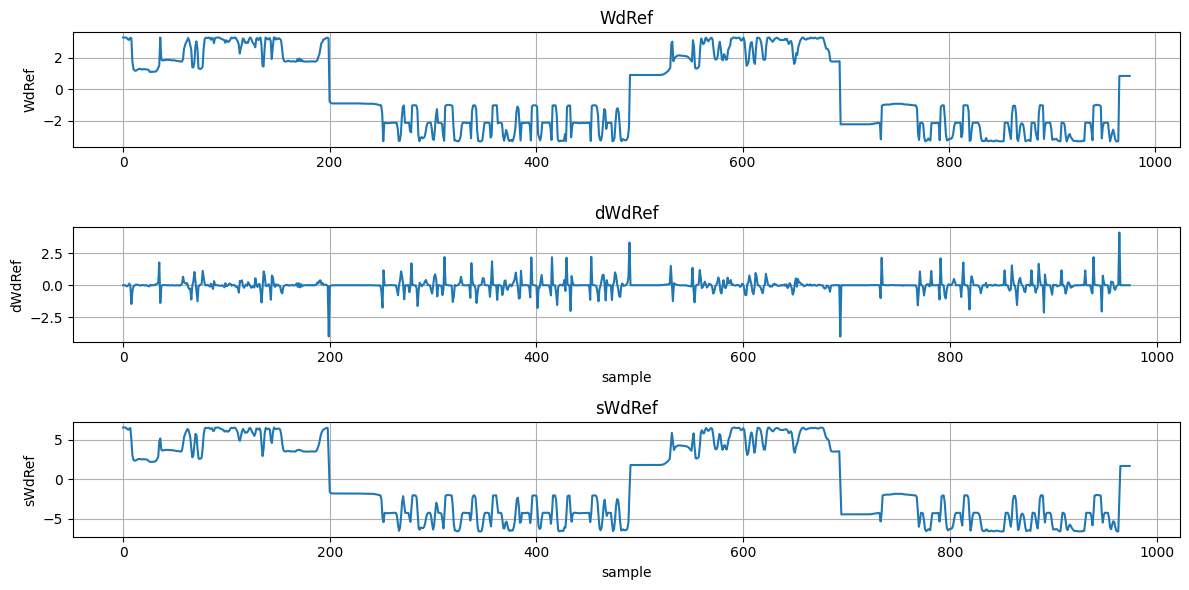

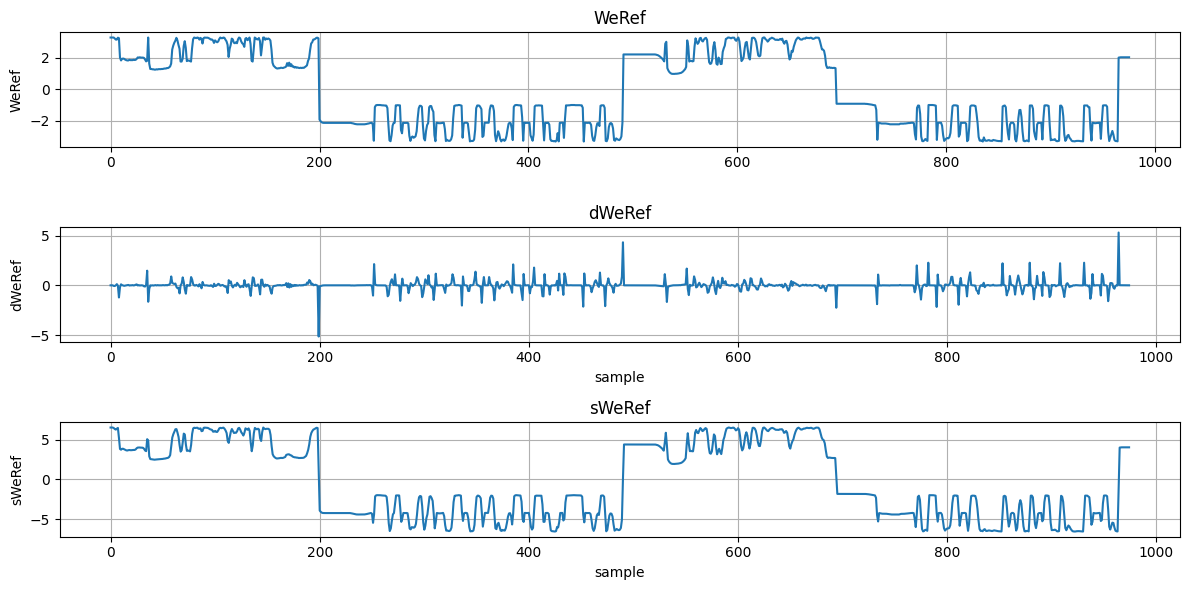

In [10]:
for pred in PREDICTORS:
    PlotPred(Datasets[0], predictor=pred)
